# Single Quantum Dot

This notebook is used to run numerical simulations of heterostructure hosting a sinlge quantum dot in 1D, 2D, and 3D. This will serve as a baseline case before scaling to larger architectures with multiple dots.

## 0. Setup

### - Imports

Import the necessary libraries and packagaes to run nextnano simulations.

In [22]:
import os
import sys
import importlib.metadata
from pathlib import Path
import numpy as np
import nextnanopy as nn
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import ipywidgets as widgets
from IPython.display import display

print("Python:", sys.version)
print("CWD:", os.getcwd())
print("nextnanopy version:", importlib.metadata.version("nextnanopy"))

Python: 3.11.13 (main, Jun  5 2025, 08:14:07) [Clang 14.0.6 ]
CWD: /Users/robertjovanov/code/qpu-design-automation-toolkit/notebooks/experiments
nextnanopy version: 1.0.3


### - Input Config

Set here all the necessary configuration parameters for the simulation.

In [5]:
# path to simulation input file
INPUT_SINGLE_DOT_1D = Path("/Users/robertjovanov/code/qpu-design-automation-toolkit"
                    "/configs/nextnano_inputs/baseline_single_qd/1d"
                    "/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in")
print("INPUT_SINGLE_DOT_1D exists:", INPUT_SINGLE_DOT_1D.exists(), INPUT_SINGLE_DOT_1D)

INPUT_SINGLE_DOT_1D exists: True /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in


## 1. 1D Simulation

### 1.1 Global Equilibrium (Empty QW)

#### - Run simulation

Load the simulation input file.

In [6]:
# simulation input file
sd_1d = nn.InputFile(str(INPUT_SINGLE_DOT_1D))
print(sd_1d)

InputFile
fullpath: /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in
Input variables: 58 elements
	$strain = 1 # run strain model
	$poisson = 0 # solve the Poisson equation with bulk densities of states
	$quantum = 0 # solve the Schroedinger equation once
	$quantum_poisson = 1 # solve the Schroedinger equation self-consistently with the Poisson equation
	$effective_model = 0 # replace c-Ge cap with the alloy and effective charges, when set to 0, ideally one should have run $quantum_poisson = 1
	$n_c_Ge_QW_HH = 10
	$n_c_Ge_QW_LH = 10
	$n_Ge_under_oxide_HH = 10
	$n_Ge_under_oxide_LH = 10
	$temperature = 0.01 # (K)
	$V_PG = -3 # (V)
	$doping_cap = 0.0 # 5e18        # (cm^-3) doping in the modulation region of the cap layer
	$doping_buffer = 0.0 # 5e18        # (cm^-3) doping in the modulation region of the buffer layer
	$dop_energy = 0.02 # (eV) activation energy of the impurity
	$surface_char

Run the simulation.

In [7]:
sd_1d.execute()


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                                                             
Th

{'process': <Popen: returncode: 0 args: '"/Applications/nextnano/2025_12_17/nextnano++/b...>,
 'outputdirectory': '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D',
 'filename': '2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D',
 'logfile': '/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.log',
 'cmd': '"/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS_old" --license "/Applications/nextnano/2025_12_17/licenses/license.txt" --database "/Applications/nextnano/2025_12_17/nextnano++/database/database.nnp" --threads 0 --outputdirectory "/Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D" --noautooutdir "/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D.in"',
 'wdir': '/Applications/nextnan

Set up access to output folder and output files from the simulation.

In [8]:
RUN_1D = Path(sd_1d.folder_output)

STRUCTURE_DIR_1D = RUN_1D / "Structure"
STRAIN_DIR_1D    = RUN_1D / "Strain"

# discover bias folders programmatically
BIAS_DIRS = sorted(p for p in RUN_1D.iterdir() if p.is_dir() and p.name.startswith("bias_"))

assert len(BIAS_DIRS) > 0, "No bias folders found"
BIAS0 = BIAS_DIRS[0]

print("Run root:      ", RUN_1D)
print("Structure dir:", STRUCTURE_DIR_1D)
print("Strain dir:   ", STRAIN_DIR_1D)
print("Bias folders: ", [p.name for p in BIAS_DIRS])

Run root:       /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D
Structure dir: /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D/Structure
Strain dir:    /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/2025-08-28_c-Ge_QW_Single_Quantum_Dot_1D/Strain
Bias folders:  ['bias_00000']


#### - Band edges

In [9]:
bandedges_path = BIAS0 / "bandedges.dat"

df_be = pd.read_csv(
    bandedges_path,
    delim_whitespace=True,
    comment="#",
)

# print(df_be.columns)
# df_be.head()

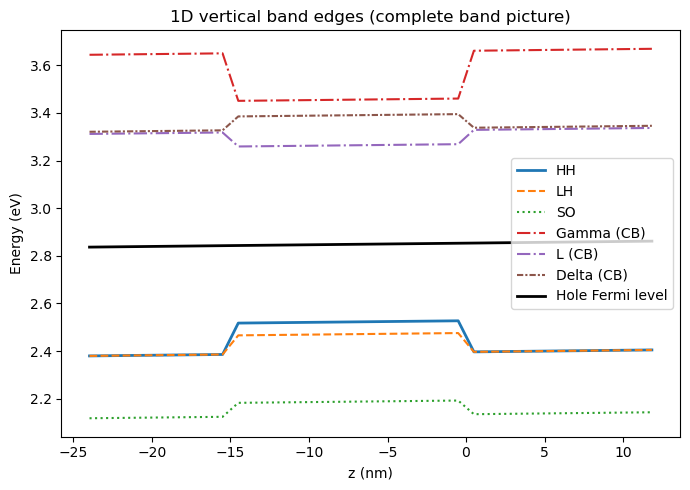

In [10]:
x = df_be["x[nm]"].iloc[194:250]

HH = df_be["HH[eV]"].iloc[194:250]
LH = df_be["LH[eV]"].iloc[194:250]
SO = df_be["SO[eV]"].iloc[194:250]

Gamma = df_be["Gamma[eV]"].iloc[194:250]
L1 = df_be["L_1[eV]"].iloc[194:250]
Delta1 = df_be["Delta_1[eV]"].iloc[194:250]

hF = df_be["hole_Fermi_level[eV]"].iloc[194:250]

plt.figure(figsize=(7, 5))

# Valence bands
plt.plot(x, HH, label="HH", linewidth=2)
plt.plot(x, LH, label="LH", linestyle="--")
plt.plot(x, SO, label="SO", linestyle=":")

# Conduction bands
plt.plot(x, Gamma, label="Gamma (CB)", linestyle="-.")
plt.plot(x, L1, label="L (CB)", linestyle="-.")

# Delta valley (CB)
plt.plot(x, Delta1, label="Delta (CB)", linestyle=(0, (3, 1, 1, 1)))  # dash-dot-dot

# Fermi level
plt.plot(x, hF, label="Hole Fermi level", color="black", linewidth=2)

plt.xlabel("z (nm)")
plt.ylabel("Energy (eV)")
plt.title("1D vertical band edges (complete band picture)")
plt.legend(loc="best")

plt.tight_layout()
plt.show()


Positive indications:
- Ordering of bands is as expected (conduction, fermi, valence), however the Fermi level is intentionally set at the middle of the bandgap
- Strain model works, there is a HH-LH split
- The SO band is much deeper and lowe in energy
- For Ge the L valley is relevant

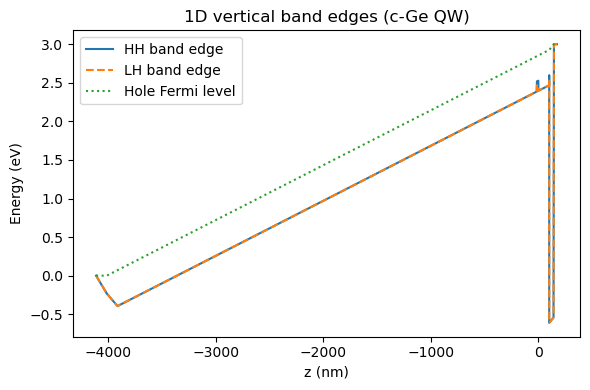

In [11]:
x = df_be["x[nm]"]
HH = df_be["HH[eV]"]
LH = df_be["LH[eV]"]
hF = df_be["hole_Fermi_level[eV]"]

plt.figure(figsize=(6, 4))

plt.plot(x, HH, label="HH band edge")
plt.plot(x, LH, label="LH band edge", linestyle="--")
plt.plot(x, hF, label="Hole Fermi level", linestyle=":")

plt.xlabel("z (nm)")
plt.ylabel("Energy (eV)")
plt.legend()
plt.title("1D vertical band edges (c-Ge QW)")

plt.tight_layout()
plt.show()

In [12]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_be["x[nm]"],
    y=df_be["HH[eV]"],
    name="HH band edge",
    mode="lines"
))

fig.add_trace(go.Scatter(
    x=df_be["x[nm]"],
    y=df_be["LH[eV]"],
    name="LH band edge",
    mode="lines"
    #line=dict(dash="dash")
))

fig.add_trace(go.Scatter(
    x=df_be["x[nm]"],
    y=df_be["hole_Fermi_level[eV]"],
    name="Hole Fermi level",
    mode="lines",
    line=dict(dash="dot")
))

fig.update_layout(
    title="1D vertical band edges",
    xaxis_title="z (nm)",
    yaxis_title="Energy (eV)",
    hovermode="x unified"
)

fig.show()


Positive indications:
- HH is higher in energy than LH 
- HH - LH split-off is present (stress tensor calculation probably works)
- skewed band edge (stress, gate potential, etc. can be causes for the band bending)
- square peak, indicates confinement already, the peak corresponds to the Germanium layer, no sharp cut-off at boundary z=-15 and z=0, doesn't span the whole quantum region

#### - Density

##### Total hole density

Index(['x[nm]', 'Hole_density[1e18_cm^-3]'], dtype='object')


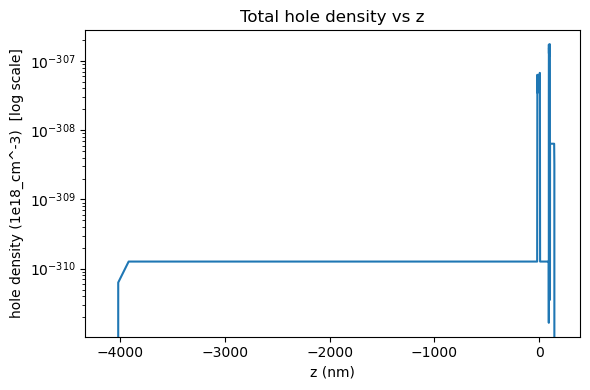

In [13]:
p = BIAS0 / "density_hole.dat"
assert p.exists(), p

df_h = pd.read_csv(p, delim_whitespace=True)
print(df_h.columns)

plt.figure(figsize=(6,4))
plt.semilogy(df_h.iloc[:,0], df_h.iloc[:,1])
plt.xlabel("z (nm)")
plt.ylabel("hole density (1e18_cm^-3)  [log scale]")
plt.title("Total hole density vs z")
plt.tight_layout()
plt.show()

In [14]:
p = BIAS0 / "density_hole.dat"
assert p.exists(), p

df_h = pd.read_csv(p, delim_whitespace=True)

z = df_h.iloc[:, 0]
p_h = df_h.iloc[:, 1]

fig = go.Figure()

# mark the Ge region in the heterostructure
fig.add_vline(x=-15, line_dash="dash")
fig.add_vline(x=0, line_dash="dash")

fig.add_trace(go.Scatter(x=z, y=p_h, mode="lines", name="hole density"))

fig.update_layout(
    title="Total hole density vs z",
    xaxis_title="z (nm)",
    yaxis_title="hole density(1e18_cm^-3)",
)

# log scale
fig.update_yaxes(type="log")

# zoom to the quantum well region
fig.update_xaxes(range=[-25, 10])

# interactive slider to quickly scan through the regions
fig.update_xaxes(rangeslider_visible=True)

fig.show()


Negative indication:
- There seems to be no accumulated charge density (essentially a numerical zero)

Positive indication:
- Is in agreement with the value in integrated_density_hole which is essentially a numerical zero

##### Quantum hole density in QW

Quantum HH density

Index(['x[nm]', 'Density[1e18_cm^-3]'], dtype='object')


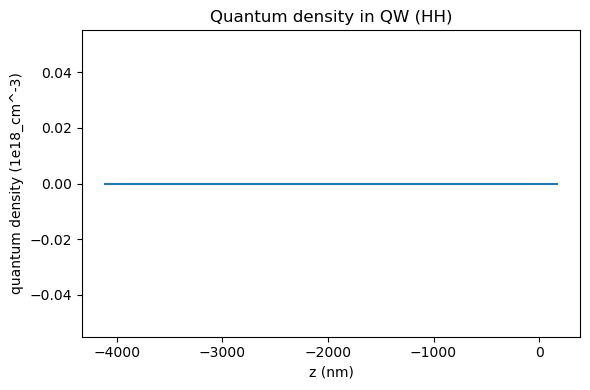

In [15]:
p_hh = BIAS0 / "Quantum" / "c-Ge_QW" / "HH" / "density.dat"
assert p_hh.exists(), p_hh

df_qhh = pd.read_csv(p_hh, delim_whitespace=True)
print(df_qhh.columns)

plt.figure(figsize=(6,4))
plt.plot(df_qhh.iloc[:,0], df_qhh.iloc[:,1])
plt.xlabel("z (nm)")
plt.ylabel("quantum density (1e18_cm^-3)")
plt.title("Quantum density in QW (HH)")
plt.tight_layout()
plt.show()

Quantum LH density

Index(['x[nm]', 'Density[1e18_cm^-3]'], dtype='object')


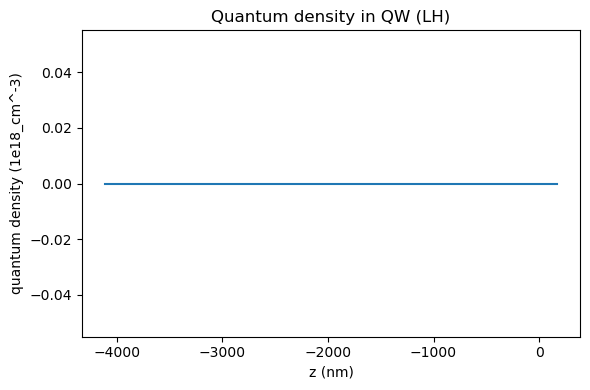

In [16]:
p_lh = BIAS0 / "Quantum" / "c-Ge_QW" / "LH" / "density.dat"
assert p_lh.exists(), p_lh

df_qlh = pd.read_csv(p_lh, delim_whitespace=True)
print(df_qlh.columns)

plt.figure(figsize=(6,4))
plt.plot(df_qlh.iloc[:,0], df_qlh.iloc[:,1])
plt.xlabel("z (nm)")
plt.ylabel("quantum density (1e18_cm^-3)")
plt.title("Quantum density in QW (LH)")
plt.tight_layout()
plt.show()

Quantum hole density

In [17]:
z_hh, rho_hh = df_qhh.iloc[:, 0], df_qhh.iloc[:, 1]
z_lh, rho_lh = df_qlh.iloc[:, 0], df_qlh.iloc[:, 1]

# Plot
fig = go.Figure()
fig.add_trace(go.Scatter(x=z_hh, y=rho_hh, mode="lines", name="Quantum HH density"))
fig.add_trace(go.Scatter(x=z_lh, y=rho_lh, mode="lines", name="Quantum LH density"))

fig.update_layout(
    title="Quantum density in c-Ge QW (HH vs LH)",
    xaxis_title="z (nm)",
    yaxis_title="Quantum density (1e18_cm^-3)",
    hovermode="x unified",
)

fig.update_yaxes(type="log")
fig.update_xaxes(range=[-25, 10])

# QW boundaries
fig.add_vline(x=-15, line_dash="dash")
fig.add_vline(x=0, line_dash="dash")

fig.show()


Negative indication:
- Even from the qunatum mechanical solutions there seems to be no accumulated charge density (essentially a numerical zero)

Positive indication:
- Is in agreement with the value in integrated_density_hole which is essentially a numerical zero, and they are all on the same order of magnitude (not sure if this is relevant)

#### - Quantum States

In [18]:
def plot_probabilities_file_one_axis(prob_file, *, title=None, show_rangeslider=True):
    """
    Plot nextnano probabilities_shift_k00000.dat on ONE set of axes:
      - x[nm] on the x-axis
      - E_1..E_5 and Psi^2_1..Psi^2_5 all as traces on the same y-axis

    Notes:
      - This mixes units (eV and nm^-1) on purpose, as requested.
      - Uses the full x-range automatically.
    """
    df = pd.read_csv(prob_file, delim_whitespace=True)

    # x column name varies; fall back to first column
    xcol = "x[nm]" if "x[nm]" in df.columns else df.columns[0]
    x = df[xcol]

    # take first 5 energy columns and first 5 Psi^2 columns (if present)
    E_cols = [c for c in df.columns if c.startswith("E_")][:5]
    P_cols = [c for c in df.columns if c.startswith("Psi^2_")][:5]
    if not E_cols and not P_cols:
        raise ValueError(f"No E_/Psi^2_ columns found in: {prob_file}")

    fig = go.Figure()

    # Energies
    for c in E_cols:
        fig.add_trace(go.Scatter(x=x, y=df[c], mode="lines", name=c))

    # Probabilities
    for c in P_cols:
        fig.add_trace(go.Scatter(x=x, y=df[c], mode="lines", name=c))

    fig.update_layout(
        title=title or f"probabilities file: {prob_file}",
        xaxis_title=xcol,
        yaxis_title="Mixed units (eV and nm⁻¹)",
        hovermode="x unified",
    )

    # fig.update_xaxes(rangeslider_visible=show_rangeslider)  # full range by default
    # fig.show()
    return fig


Bound states in HH (eigenenergies and eigenstates)

In [19]:
plot_probabilities_file_one_axis(
    BIAS0 / "Quantum" / "c-Ge_QW" / "HH" / "probabilities_shift_k00000.dat",
    title="Bound states (eigenvalues and eigenstates) of HH"
)


Bound states in LH (eigenenergies and eigenstates)

In [20]:
plot_probabilities_file_one_axis(
    BIAS0 / "Quantum" / "c-Ge_QW" / "LH" / "probabilities_shift_k00000.dat",
    title="Bound states (eigenvalues and eigenstates) of LH"
)


#### - Potential

In [28]:
df_pot = pd.read_csv(BIAS0 / "potential.dat", delim_whitespace=True)

x = df_pot["x[nm]"]
phi = df_pot["Potential[V]"]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x,
        y=phi,
        mode="lines",
        name="Electrostatic potential",
        line=dict(width=3)
    )
)

fig.update_layout(
    title="Electrostatic Potential",
    xaxis_title="z (nm)",
    yaxis_title="Potential (V)",
    template="plotly_white",
    height=500
)

fig.show()


In [29]:
# ---- load data ----
df_pot = pd.read_csv(BIAS0 / "potential.dat", delim_whitespace=True)
x = df_pot["x[nm]"].to_numpy()
y = df_pot["Potential[V]"].to_numpy()

# ---- figurewidget ----
fig = go.FigureWidget(
    data=[go.Scatter(x=x, y=y, mode="lines", name="Potential")],
    layout=go.Layout(
        title="Electrostatic Potential",
        template="plotly_white",
        height=500,
        xaxis=dict(title="z (nm)"),
        yaxis=dict(title="Potential (V)"),
    ),
)

# ---- controls ----
xmin_w = widgets.FloatText(value=-20.0, description="x_min", step=1.0)
xmax_w = widgets.FloatText(value=5.0, description="x_max", step=1.0)
pad_w  = widgets.FloatSlider(value=0.05, min=0.0, max=0.3, step=0.01, description="y pad")
btn    = widgets.Button(description="Apply", button_style="primary")
msg    = widgets.HTML("")

def apply_range(_=None):
    xmin, xmax = float(xmin_w.value), float(xmax_w.value)
    if xmax <= xmin:
        msg.value = "<b style='color:#b00'>x_max must be > x_min</b>"
        return

    m = (x >= xmin) & (x <= xmax)
    if not np.any(m):
        msg.value = "<b style='color:#b00'>No data points in that interval.</b>"
        return

    y_win = y[m]
    ymin, ymax = float(np.nanmin(y_win)), float(np.nanmax(y_win))
    pad = (ymax - ymin) * float(pad_w.value) if ymax > ymin else 1e-9

    with fig.batch_update():
        fig.layout.xaxis.range = [xmin, xmax]
        fig.layout.yaxis.range = [ymin - pad, ymax + pad]

    msg.value = ""

btn.on_click(apply_range)

# initialize view
apply_range()

display(widgets.HBox([xmin_w, xmax_w, pad_w, btn]), msg, fig)


HTML(value='')

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'Potential',
              'type': 'scatter',
              'uid': '28aad072-51b5-456a-a6ee-3f485e8eaf81',
              'x': {'bdata': ('AAAAAAATsMAAAAAAAF6vwABLOoxhl6' ... 'AAACBlQAAAAAAAYGVAAAAAAACgZUA='),
                    'dtype': 'f8'},
              'y': {'bdata': ('pd5fBnIWAUBbaWgGchYBQMrKbOxrhQ' ... 'A9Ctfrv9ejcD0K1+u/16NwPQrX678='),
                    'dtype': 'f8'}}],
    'layout': {'height': 500,
               'template': '...',
               'title': {'text': 'Electrostatic Potential'},
               'xaxis': {'range': [-20.0, 5.0], 'title': {'text': 'z (nm)'}},
               'yaxis': {'range': [-0.730916455117302, -0.711797856978618], 'title': {'text': 'Potential (V)'}}}
})

#### - Electric Field

In [25]:
df_E = pd.read_csv(BIAS0 / "electric_field.dat", delim_whitespace=True)

x = df_E["x[nm]"]
E = df_E["E[kV/cm]"]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=x,
        y=E,
        mode="lines",
        name="Electric field",
        line=dict(width=3)
    )
)

fig.update_layout(
    title="Electric Field",
    xaxis_title="z (nm)",
    yaxis_title="Electric Field (kV/cm)",
    template="plotly_white",
    height=500
)

fig.show()


### 1.2 Effective Surface Charge Model

#### - Run simulation

First let's turn on the effective model which adds a sheet charge density of 9.93016e+11(cm^-2) (estimated value) in the Ge cap layer.

In [43]:
# turn on effective model
sd_1d.set_variable('effective_model', value=1)
sd_1d.save('/Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/Single_Quantum_Dot_effective_model_1D.in')

# Run simulation
sd_1d.execute()

print("Output folder:", sd_1d.folder_output)


PREPARING...

Checking input files...


Reading environment and checking paths...

RUNNING..
Starting execution as:
/Applications/nextnano/2025_12_17/nextnano++/bin/nextnano++_gcc_macOS --old --license /Applications/nextnano/2025_12_17/licenses/license.txt --database /Applications/nextnano/2025_12_17/nextnano++/database/database.nnp --threads 0 --outputdirectory /Users/robertjovanov/code/qpu-design-automation-toolkit/runs/Single_Quantum_Dot_effective_model_1D_0 --noautooutdir /Users/robertjovanov/code/qpu-design-automation-toolkit/configs/nextnano_inputs/baseline_single_qd/1d/Single_Quantum_Dot_effective_model_1D_0.in 

nextnano++ 2.4.27 from 2025-12-16 (library 2025-07-29)
COPYRIGHT NOTICE                                                             
ANY USE OF THE NEXTNANO++ CODE CONSTITUTES ACCEPTANCE OF THE TERMS OF THE    
COPYRIGHT NOTICE.                                                            
                                                                             
The 

In [108]:
RUN = Path(sd_1d.folder_output)
BIAS0 = RUN / "bias_00000"

# Toggle zoom on/off here
ZOOM_QW = True
QW_XRANGE = [-20, 5]   # quantum region

def read_nn_dat(path: Path):
    return pd.read_csv(path, delim_whitespace=True, comment="#")

def plot_lines(df, xcol, ycols, title, y_label="", zoom=ZOOM_QW):
    fig = go.Figure()
    x = df[xcol]

    for c in ycols:
        if c in df.columns:
            fig.add_trace(go.Scatter(x=x, y=df[c], mode="lines", name=c))
        else:
            print(f"Column not found: {c}")

    fig.update_layout(
        title=title,
        xaxis_title="z (nm)",
        yaxis_title=y_label,
        template="plotly_white",
        height=520
    )

    if zoom:
        fig.update_xaxes(range=QW_XRANGE)

    fig.show()


#### - Band edges

In [109]:
df_be = read_nn_dat(BIAS0 / "bandedges.dat")

plot_lines(
    df_be,
    xcol="x[nm]",
    ycols=[
        "HH[eV]", "LH[eV]", "SO[eV]",
        "Gamma[eV]",
        "Delta_1[eV]", "Delta_2[eV]", "Delta_3[eV]",
        "L_1[eV]", "L_2[eV]", "L_3[eV]", "L_4[eV]",
        "electron_Fermi_level[eV]", "hole_Fermi_level[eV]"
    ],
    title="Band edges + Fermi levels",
    y_label="Energy (eV)"
)


#### - Potential

In [110]:
df_pot = read_nn_dat(BIAS0 / "potential.dat")

plot_lines(
    df_pot,
    xcol="x[nm]",
    ycols=["Potential[V]"],
    title="Electrostatic potential",
    y_label="Potential (V)"
)


#### - Electric Field

In [111]:
df_ef = read_nn_dat(BIAS0 / "electric_field.dat")

plot_lines(
    df_ef,
    xcol="x[nm]",
    ycols=["E[kV/cm]"],
    title="Electric field",
    y_label="E (kV/cm)"
)


#### - Density

In [113]:
df_e = read_nn_dat(BIAS0 / "density_electron.dat")

electron_col = next(c for c in df_e.columns if "Electron_density" in c)

plot_lines(
    df_e,
    xcol="x[nm]",
    ycols=[electron_col],
    title="Electron density",
    y_label=electron_col
)

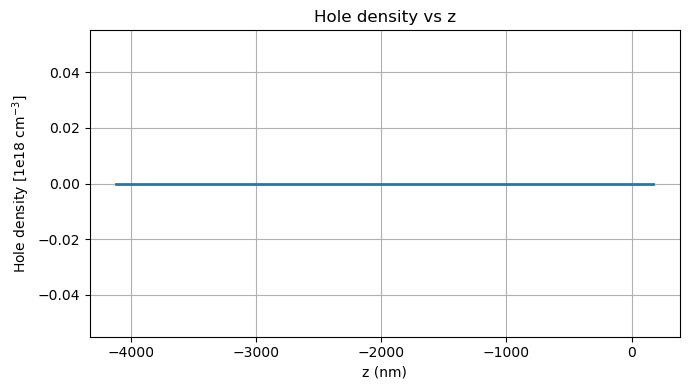

In [116]:
# Read file
df_h = pd.read_csv(BIAS0 / "density_hole.dat", delim_whitespace=True)

# Extract columns
x = df_h["x[nm]"]
y = df_h["Hole_density[1e18_cm^-3]"]

# Plot
plt.figure(figsize=(7,4))
plt.plot(x, y, linewidth=2)
plt.xlabel("z (nm)")
plt.ylabel("Hole density [1e18 cm$^{-3}$]")
plt.title("Hole density vs z")
plt.grid(True)
plt.tight_layout()
plt.show()


#### - Quantum States

In [118]:
plot_probabilities_file_one_axis(
    BIAS0 / "Quantum" / "c-Ge_QW" / "HH" / "probabilities_shift_k00000.dat",
    title="Bound states (eigenvalues and eigenstates) of HH"
)

In [120]:
plot_probabilities_file_one_axis(
    BIAS0 / "Quantum" / "c-Ge_QW" / "LH" / "probabilities_shift_k00000.dat",
    title="Bound states (eigenvalues and eigenstates) of LH"
)